In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/autism-detection/Fin_dataset/Autistic/0664.jpg
/kaggle/input/autism-detection/Fin_dataset/Autistic/1269.jpg
/kaggle/input/autism-detection/Fin_dataset/Autistic/0733.jpg
/kaggle/input/autism-detection/Fin_dataset/Autistic/Copy of Autistic.399.jpg
/kaggle/input/autism-detection/Fin_dataset/Autistic/Copy of Copy of Autistic.200.jpg
/kaggle/input/autism-detection/Fin_dataset/Autistic/0106.jpg
/kaggle/input/autism-detection/Fin_dataset/Autistic/0375.jpg
/kaggle/input/autism-detection/Fin_dataset/Autistic/1075.jpg
/kaggle/input/autism-detection/Fin_dataset/Autistic/0285.jpg
/kaggle/input/autism-detection/Fin_dataset/Autistic/Autistic1 (70).png
/kaggle/input/autism-detection/Fin_dataset/Autistic/0591.jpg
/kaggle/input/autism-detection/Fin_dataset/Autistic/Autistic1 (1).png
/kaggle/input/autism-detection/Fin_dataset/Autistic/0799.jpg
/kaggle/input/autism-detection/Fin_dataset/Autistic/1411.jpg
/kaggle/input/autism-detection/Fin_dataset/Autistic/0074.jpg
/kaggle/input/autism-detec

In [2]:
import cv2
import dlib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [3]:
# Load face detector and landmark predictor
face_detector = dlib.get_frontal_face_detector()
landmark_predictor = dlib.shape_predictor("/kaggle/input/dat-file/shape_predictor_68_face_landmarks.dat")

In [4]:
def extract_landmarks(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_detector(gray)
    if len(faces) == 0:
        return None
    landmarks = landmark_predictor(gray, faces[0])
    return np.array([(p.x, p.y) for p in landmarks.parts()])

In [5]:
def compute_features(landmarks):
    # Implement your feature extraction logic here
    # Example: distances between key points
    features = []
    for i in range(len(landmarks)):
        for j in range(i+1, len(landmarks)):
            dist = np.linalg.norm(landmarks[i] - landmarks[j])
            features.append(dist)
    return np.array(features)

In [6]:
def compute_ratio_features(landmarks):
    # """
    # Computes ratio-based features:
    #   - Face aspect ratio: width / height of the face (based on landmarks bounding box)
    #   - Eye Aspect Ratio (EAR) for left and right eyes (if available)
    
    # Assumes landmarks is a numpy array of shape (N, 2), with N >= 48 for the eyes.
    # """
    # Face aspect ratio: bounding box width/height
    x_coords = landmarks[:, 0]
    y_coords = landmarks[:, 1]
    face_width = np.max(x_coords) - np.min(x_coords)
    face_height = np.max(y_coords) - np.min(y_coords)
    face_aspect_ratio = face_width / face_height if face_height != 0 else 0

    # Define a helper function for calculating EAR for one eye.
    def eye_aspect_ratio(eye_points):
        # EAR = (||p2 - p6|| + ||p3 - p5||) / (2 * ||p1 - p4||)
        A = np.linalg.norm(eye_points[1] - eye_points[5])
        B = np.linalg.norm(eye_points[2] - eye_points[4])
        C = np.linalg.norm(eye_points[0] - eye_points[3])
        return (A + B) / (2.0 * C) if C != 0 else 0

    # Check if landmarks contain enough points for eye landmarks
    if len(landmarks) >= 48:
        # Using dlib's 68-point model indices:
        left_eye = landmarks[36:42]
        right_eye = landmarks[42:48]
        left_ear = eye_aspect_ratio(left_eye)
        right_ear = eye_aspect_ratio(right_eye)
    else:
        left_ear = right_ear = 0

    # Return the computed ratios as a feature vector
    return np.array([face_aspect_ratio, left_ear, right_ear])


In [7]:
def compute_angular_features(landmarks):
    # """
    # Computes angular features:
    #   - Head tilt angle based on the line connecting the centers of the eyes.
    
    # Assumes landmarks is a numpy array of shape (N, 2), with N >= 48 for the eyes.
    # """
    if len(landmarks) >= 48:
        # Calculate the centers of the left and right eyes (using dlib's indices)
        left_eye_center = np.mean(landmarks[36:42], axis=0)
        right_eye_center = np.mean(landmarks[42:48], axis=0)
        # Compute the differences in x and y coordinates
        delta_y = right_eye_center[1] - left_eye_center[1]
        delta_x = right_eye_center[0] - left_eye_center[0]
        # Calculate the angle in degrees
        angle = np.degrees(np.arctan2(delta_y, delta_x))
    else:
        angle = 0
    return np.array([angle])


In [8]:
import cv2
import numpy as np

def compute_shape_features(landmarks):
    # """
    # Computes shape descriptors from the facial landmarks:
    #   - Area of the convex hull of the landmarks.
    #   - Perimeter of the convex hull.
    #   - Compactness: (perimeter^2 / area), a measure of the shape.
    
    # Assumes landmarks is a numpy array of shape (N, 2).
    # """
    # Convert landmarks to integer type (required by cv2.convexHull)
    points = landmarks.astype(np.int32)
    hull = cv2.convexHull(points)
    # Calculate area and perimeter
    area = cv2.contourArea(hull)
    perimeter = cv2.arcLength(hull, True)
    # Calculate compactness; avoid division by zero
    compactness = (perimeter ** 2) / area if area != 0 else 0
    return np.array([area, perimeter, compactness])


In [9]:
def compute_all_features(landmarks):
    features = []
    # Extend the list with the elements from each feature set
    features.extend(compute_features(landmarks).tolist())
    features.extend(compute_ratio_features(landmarks).tolist())
    features.extend(compute_angular_features(landmarks).tolist())
    # features.extend(compute_shape_features(landmarks).tolist())
    return np.array(features)

In [10]:
dataset = [
    ("/kaggle/input/autism-detection/Fin_dataset/Non-Autistic", 0),
    ("/kaggle/input/autism-detection/Fin_dataset/Autistic", 1),
]
X = []
y = []
for folder, label in dataset:
    # List all files in the directory
    for file in os.listdir(folder):
        # Construct the full file path
        file_path = os.path.join(folder, file)
        image = cv2.imread(file_path)
        if image is None:
            # Skip if the image could not be loaded
            print(f"Skipping file: {file_path}")
            continue
        landmarks = extract_landmarks(image)
        if landmarks is not None:
            features = compute_all_features(landmarks)
            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# def diff_svc():

#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#     clf = SVC(kernel='rbf', C=1000)
#     return

In [13]:
# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svc', SVC(kernel='rbf'))
# ])

# param_grid = {
#     'svc__C': [1000, 10000,100000],
#     'svc__gamma': [1e-3, 1e-2, 1e-1, 1, 10]
# }

In [14]:
# gridsearch = GridSearchCV(pipeline, param_grid, cv = 5)
# gridsearch.fit(X_train, y_train)

In [15]:
# print("Best parameters:", gridsearch.best_params_)
# print("Best cross-validation score: {:.2f}".format(gridsearch.best_score_))

In [16]:
# best_model = gridsearch.best_estimator_
# predictions = best_model.predict(X_test)

In [17]:
# # Split dataset and train model
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# clf = SVC(kernel='rbf', C=1000, gamma=0.001)
# clf.fit(X_train, y_train)

In [18]:
X_train.shape

(2639, 2282)

In [19]:
# # Evaluate
# # y_pred = clf.predict(X_test)
# print(classification_report(y_test, predictions))

In [20]:
# from sklearn.metrics import confusion_matrix, classification_report
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Generate predictions
# y_pred = clf.predict(X_test)

# # Print classification report
# print(classification_report(y_test, y_pred))

# # Compute the confusion matrix
# cm = confusion_matrix(y_test, y_pred)
# print("Confusion Matrix:")
# print(cm)

# # Visualize the confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
# plt.ylabel("Actual")
# plt.xlabel("Predicted")
# plt.title("Confusion Matrix")
# plt.show()


# XGBoost

In [21]:
import xgboost as xgb

model = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.08, max_depth=10, random_state=42)

model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [22]:
# param_grid = {
#     'n_estimators': [100, 300, 500, 1000, 1500, 2000],
#     'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
#     'max_depth': [4, 5, 7, 10, 12, 15],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0],
#     'gamma': [0, 0.1, 0.2],
#     'reg_alpha': [0, 0.1, 1],
#     'reg_lambda': [1, 1.5, 2]
# }

In [23]:
# grid_search = GridSearchCV(xgb.XGBClassifier(random_state=42),
#                            param_grid,
#                            cv=5,
#                            n_jobs=-1,
#                            verbose=1)
# grid_search.fit(X_train, y_train)

In [24]:
# print("Best parameters:", gridsearch.best_params_)
# print("Best cross-validation score: {:.2f}".format(gridsearch.best_score_))

In [25]:
# best_model = gridsearch.best_estimator_
# predictions = best_model.predict(X_test)

In [26]:
# print(classification_report(y_test, predictions))

In [27]:
# from sklearn.metrics import ConfusionMatrixDisplay
# ConfusionMatrixDisplay(best_model,X_test,y_test)

In [28]:
y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81       348
           1       0.79      0.78      0.79       312

    accuracy                           0.80       660
   macro avg       0.80      0.80      0.80       660
weighted avg       0.80      0.80      0.80       660



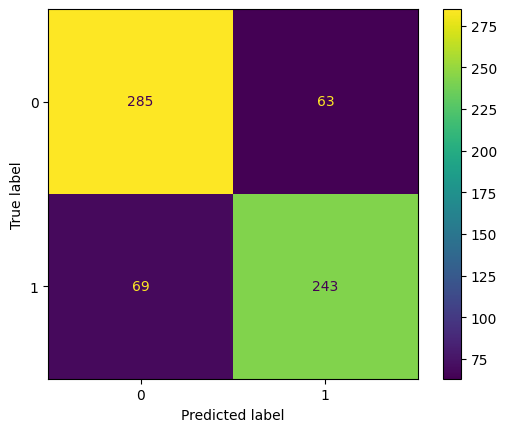

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)

In [1]:
model.save_model('xgb_model_upto_best.json')

NameError: name 'model' is not defined